# Camera-based bi-axial measurement of weak forces generated by freely moving plant organs — force-extraction reproduction

Reproduction of the force-extraction pipeline of:

> Ohad, A. & Meroz, Y. (2025). *Camera-based bi-axial measurement of weak forces generated by freely moving plant organs.* **Journal of Experimental Botany** 77(4):985–994. DOI: [10.1093/jxb/eraf476](https://doi.org/10.1093/jxb/eraf476)

**Purpose.** A freely moving (non-tethered) plant shoot pushes against a physical-pendulum support. Two orthogonal cameras track the support and the contact point; from the rod deflection angle and a torque-equilibrium equation, the bi-axial force applied by the shoot over time is extracted (mN). This notebook re-runs the **authors' own analysis notebook** (`article0_notebook.ipynb` + `article0_funcs.py`) on the authors' released example tracking data and regenerates (A) the deflection/angle/force-trajectory figure for one shoot–support contact event and (B) the force-calibration and measurement-noise figure.

**Sources (pinned).**
- Author code: [`merozlab/Ohad2025_PendulumForceMeasure`](https://github.com/merozlab/Ohad2025_PendulumForceMeasure) @ commit `c4b7f7b05e559aeb22c596f163e9ccfd1e607b70` (branch `Article0_v3`)
- Data: same repository `Data/` folders; full deposit (incl. raw images) on Zenodo DOI [10.5281/zenodo.15545548](https://doi.org/10.5281/zenodo.15545548)

**Scope (partial demonstration).** Re-run of the authors' example-data analysis exactly as their notebook does, minus raw-video re-tracking (7.2 GB `Example_images.zip`, not needed — the authors' notebook consumes pre-extracted tracking `.txt` files) and minus hardware/GUI elements. One example set (5 plants / 10 tracked rows) in, two figures plus a small summary table out. **This is a one-example re-execution, not verification of the paper's dataset-level results.**

**Execution status.** Intended to run **top-to-bottom on a free Colab CPU runtime** in a few minutes (~1 MB of downloads). No GPU is used (pure NumPy/Pandas/SciPy/Matplotlib physics computation).

**Adaptation notice (AI-assisted adaptation).** The analysis code in this notebook is copied **verbatim from the authors' pinned commit**; the authors did not provide a Linux/Colab version. The only modifications are three minimal, marked `# ADAPTED` path fixes for Windows→Linux (path separators and a folder-name case), plus added provenance/preview/summary cells. Untested behavior beyond the executed example is not guaranteed. 出典: 著者リポジトリ (commit `c4b7f7b0...`) の解析コードをそのまま使用し、Linux 用のパス修正のみ加えています。

**日本語要約.** 自由に運動する植物器官が発する弱い力を、振り子のたわみと2直交カメラのトラッキングからトルク釣り合いにより推定する論文の解析パイプラインを、著者公開の例データでそのまま再実行します。GPU 不要、無料 CPU ランタイムで数分で完了します。

## 1. Runtime: use a free **CPU** runtime (ランタイム タイプ: CPU)

**Runtime selection.** The method is a deterministic NumPy/SciPy computation on <1 MB of coordinate tables — there is no neural network and no CUDA code anywhere in the authors' import graph (`article0_funcs.py` imports numpy/scipy/seaborn/h5py/matplotlib only). A GPU would not change any result, so **CPU is the faithful and recommended runtime**; do not request a GPU.

**Run all:** `Runtime → Run all` (ランタイム → すべての実行). Expected: ~1 min downloads + a few minutes total on a free CPU runtime (estimates; measured times are printed by the cells).

The next cell reports the actual environment. `openpyxl` is required to read the authors' `.xlsx` tables; it is preinstalled on Colab and only installed if missing.

In [ ]:
import os, sys, platform
print('Python', sys.version.split()[0], '|', platform.machine())
import numpy, pandas, scipy, matplotlib
print('numpy', numpy.__version__, '| pandas', pandas.__version__,
      '| scipy', scipy.__version__, '| matplotlib', matplotlib.__version__)
try:
    import openpyxl
    print('openpyxl', openpyxl.__version__)
except ImportError:
    %pip install -q openpyxl
    import openpyxl
    print('openpyxl installed', openpyxl.__version__)
print('CPU cores:', os.cpu_count())

Python 3.13.16 | x86_64


numpy 2.1.3 | pandas 2.2.3 | scipy 1.16.3 | matplotlib 3.10.0


openpyxl 3.1.5
CPU cores: 2


## 2. Working directory

The authors' notebook expects to run from the repository root, with `article0_funcs.py` importable and a `Data/` folder beside it. We recreate that layout under `/content/pendulum_article0` inside the Colab VM (all bytes stay on the remote runtime). コロボVM内に著者ノートブックと同じレイアウトを作成します。

In [ ]:
import os
ARTICLE_DIR = '/content/pendulum_article0'
os.makedirs(ARTICLE_DIR, exist_ok=True)
os.chdir(ARTICLE_DIR)
print('Working directory:', os.getcwd())

Working directory: /content/pendulum_article0


## 3. Acquire the pinned author code + example data (provenance-checked)

Smallest practical route: the example tables ship inside the author repository itself, so we query the **GitHub tree API once for the exact pinned commit** `c4b7f7b05e559aeb22c596f163e9ccfd1e607b70`, select only the files the notebook consumes, and download each from the pinned raw URL. Every file is verified against its **git blob SHA-1 and recorded size** from the tree response before use. The 7.2 GB raw-image archive is deliberately not downloaded.

Expected selection (asserted below): `article0_funcs.py` (code), `Data/example_events.xlsx`, 10 × `Data/Example_Track/*.txt`, 6 × `Data/Example_Contact/*.txt`, 1 × `Data/Fluctuations/CSRT_fluctuations_1sec_interval.txt`, 1 × `Data/Force calibration/force_calibration_curve.xlsx` — 20 files, ≈0.9 MB total. ピン留したコミットから必要な20ファイルのみ取得し、SHA-1で検証します。

In [ ]:
import json, hashlib, time, urllib.request, urllib.parse

COMMIT = 'c4b7f7b05e559aeb22c596f163e9ccfd1e607b70'
REPO = 'merozlab/Ohad2025_PendulumForceMeasure'
DIR_PREFIXES = ('Data/Example_Track/', 'Data/Example_Contact/', 'Data/Fluctuations/')
EXACT_FILES = ('Data/example_events.xlsx',
               'Data/Force calibration/force_calibration_curve.xlsx',
               'article0_funcs.py')

def http_get(url, tries=3):
    for attempt in range(tries):
        try:
            req = urllib.request.Request(url, headers={'User-Agent': 'colab-repro-notebook'})
            with urllib.request.urlopen(req, timeout=120) as r:
                return r.read()
        except urllib.error.HTTPError as e:
            if e.code in (403, 429) and attempt < tries - 1:  # shared anonymous limits
                time.sleep(min(int(e.headers.get('Retry-After', 10)), 30))
                continue
            raise

tree = json.loads(http_get(f'https://api.github.com/repos/{REPO}/git/trees/{COMMIT}?recursive=1'))
assert not tree.get('truncated', False), 'tree truncated - refusing to proceed'
wanted = [t for t in tree['tree'] if t['type'] == 'blob' and
          (t['path'] in EXACT_FILES or t['path'].startswith(DIR_PREFIXES))]

def blob_sha1(b):  # git blob object hash
    return hashlib.sha1(b'blob %d\0' % len(b) + b).hexdigest()

total = 0
for t in wanted:
    url = 'https://raw.githubusercontent.com/%s/%s/%s' % (REPO, COMMIT, urllib.parse.quote(t['path']))
    content = http_get(url)
    assert len(content) == t['size'], f"size mismatch: {t['path']}"
    assert blob_sha1(content) == t['sha'], f"sha mismatch: {t['path']}"
    dest = os.path.join(ARTICLE_DIR, t['path'])
    os.makedirs(os.path.dirname(dest), exist_ok=True)
    with open(dest, 'wb') as f:
        f.write(content)
    total += len(content)
    print(f"OK  {t['path']}  ({t['size']:,} B)")

# expected minimal selection (authors' notebook consumes exactly these)
by_dir = {}
for t in wanted:
    d = os.path.dirname(t['path'])
    by_dir[d] = by_dir.get(d, 0) + 1
assert len(wanted) == 20, wanted
assert by_dir['Data/Example_Track'] == 10 and by_dir['Data/Example_Contact'] == 6
assert by_dir['Data/Fluctuations'] == 1
print(f'\nVerified {len(wanted)} files, {total/1e6:.2f} MB, commit {COMMIT[:12]}')

OK  Data/Example_Contact/CSRT_0110_1_side_contact.txt  (40,013 B)
OK  Data/Example_Contact/CSRT_0111_1_side_contact.txt  (90,059 B)


OK  Data/Example_Contact/CSRT_021_1_side_contact.txt  (48,826 B)
OK  Data/Example_Contact/CSRT_036_1_side_contact.txt  (54,154 B)


OK  Data/Example_Contact/CSRT_051_1_side_contact.txt  (31,223 B)
OK  Data/Example_Contact/CSRT_058_1_side_ contact.txt  (18,461 B)


OK  Data/Example_Track/CSRT_0110_side_1.txt  (42,537 B)
OK  Data/Example_Track/CSRT_0110_top_1.txt  (54,594 B)


OK  Data/Example_Track/CSRT_021_1_side.txt  (68,219 B)
OK  Data/Example_Track/CSRT_021_1_top.txt  (67,893 B)


OK  Data/Example_Track/CSRT_036_1_side.txt  (66,838 B)
OK  Data/Example_Track/CSRT_036_1_top.txt  (66,971 B)


OK  Data/Example_Track/CSRT_051_1_side.txt  (35,961 B)
OK  Data/Example_Track/CSRT_051_1_top.txt  (37,906 B)


OK  Data/Example_Track/CSRT_058_side_1.txt  (18,055 B)
OK  Data/Example_Track/CSRT_058_top_1.txt  (18,486 B)


OK  Data/Fluctuations/CSRT_fluctuations_1sec_interval.txt  (21,676 B)
OK  Data/Force calibration/force_calibration_curve.xlsx  (15,027 B)


OK  Data/example_events.xlsx  (11,499 B)
OK  article0_funcs.py  (17,680 B)

Verified 20 files, 0.83 MB, commit c4b7f7b05e55


## 4. Import libraries and the authors' functions module (author notebook cell 1, verbatim)

Loads the scientific stack and imports `article0_funcs.py` — the module containing the `Plant`/`Event` classes, the tracked-data reader, the angle calculation, and the torque-equilibrium force formula
`F = g·m_sup·L_sup·tan(α) / (2·l_contact)` (in cgs units, converted dyne→mN; `article0_funcs.calc_F_2`, gcgs=980, dyne2mN=1/100).
The printed path should be the working directory set above. 著者のセル1をそのまま実行し、関数モジュールを読み込みます。

In [ ]:
# import libraries
# general
import sys
import numpy as np
import os,glob # for listing files in folder
import re # regular expressions
import pandas as pd
import scipy
import math as m
from tqdm import tqdm

# plots
import importlib
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
import matplotlib.lines as mlines
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Plant and Event function file
import article0_funcs

# plot parameters
cmap = plt.get_cmap('viridis')
fs = 16 # standard font size for plots


print(os.getcwd())
Article_folder = os.getcwd()

save_folder = os.path.join(Article_folder,'test_Figures')

# sys.path.append('..')
# import useful_functions as uf 
# importlib.reload(uf)
# Article_folder = r'C:\Users\Amir\Documents\PHD\Thesis\My Articles\0 - Flexible dynamic force measurement method via physical pendulum'
importlib.reload(article0_funcs)


/content/pendulum_article0/article0_funcs.py:294: SyntaxWarning: invalid escape sequence '\d'
  if re.findall('\d{4,5}',file):
/content/pendulum_article0/article0_funcs.py:295: SyntaxWarning: invalid escape sequence '\d'
  frame.append(int(re.findall('\d{4,5}',file)[0]))


/content/pendulum_article0


<module 'article0_funcs' from '/content/pendulum_article0/article0_funcs.py'>

## 5. Plot helper functions (author notebook cell 2, verbatim)

Defines the authors' figure utilities: a coarse-grid formatter (`set_grid`), a linear fit with error bars used for the calibration curve (`fit_w_err` + `linfunc`), and a lightweight tracked-data reader `funcget_tracked_data` that parses the CSRT box-center `.txt` files (comma-separated `x_top_left, y_top_left, w, h, ..., filename, timestamp` rows) and returns box centers with a 1 s/step timer. No output expected. 図の補助関数（著者セル2）を定義します。

In [ ]:
# Define functions for plots

def round_to_first_significant_digit(num):
    if num == 0:
        return 0
    
    # Find the order of magnitude (e.g., for 456, magnitude is 10^2)
    magnitude = m.floor(m.log10(abs(num)))
    
    # Normalize the number to have its first significant digit as the most significant
    normalized_num = num / (10 ** magnitude)
    
    # Round to 1 significant digit
    rounded_num = round(normalized_num, 1)
    
    # Scale the number back to the original magnitude
    return rounded_num * (10 ** magnitude)

def set_grid(ax,x_range,y_range): 

    '''set grid for plot. take 1/5 of each range for major grid, 1/10 for minor'''
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='both', direction='in', length=5,
                   width=1, colors='black', grid_color='gray', grid_alpha=0.7)
    # Set major and minor grid spacing for x-axis and y-axis
    x_major_locator = plt.MultipleLocator(x_range / 5)
    x_minor_locator = plt.MultipleLocator(x_range / 10)
    y_major_locator = plt.MultipleLocator(y_range / 5)
    y_minor_locator = plt.MultipleLocator(y_range / 10)

    ax.xaxis.set_major_locator(x_major_locator)
    ax.xaxis.set_minor_locator(x_minor_locator)
    ax.yaxis.set_major_locator(y_major_locator)
    ax.yaxis.set_minor_locator(y_minor_locator)

    # Set major and minor tick labels with rounding to the first significant digit
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{round_to_first_significant_digit(x):g}'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{round_to_first_significant_digit(y):g}'))

def linfunc(x,a,b): return a*x + b

def funcget_tracked_data(filename,view=[],camera='nikon'):
    '''get tracked data from file, return x,y,t, index, N- # of lines, C-max tracked obj,T-# of points per track'''
    with open(filename,"r") as datafile:
        lines= datafile.readlines()
        # del lines[0] # remove first line to avoid 2 zero times
        N=np.size(lines,0) # number of lines
        xtl=[[]]*N # x top left
        ytl=[[]]*N # y top left
        w=[[]]*N # box width
        h=[[]]*N # box height
        xcntr=[[]]*N # box x center
        ycntr=[[]]*N # box y center
        timer = np.zeros(N) # initialize timer array
        timer[0]=0 # time starts at zero
        i=0 # count rows
        index = 0
    # x,y,w,h ; start at upper left corner
        for line in lines:
            if line==[]: break
            currentline = line.split(",") # split by ','
            xtl[i]=float(currentline[0]) # xtl- x top left
            ytl[i]=float(currentline[1])
            w[i]=float(currentline[2])
            h[i]=float(currentline[3])
            xcntr[i]=xtl[i]+w[i]/2 # calculate x coordinate of box center
            ycntr[i]=ytl[i]-h[i]/2
            i+=1
            if i%50 ==0: 
                print(i)
                print(currentline)

        # timer = np.zeros(N) # initialize timer array
        dt = 1 # interval
        for i in range(N):
            timer[i] = timer[i-1]+dt # assign timer value for each index
        return xcntr,ycntr,timer,index,N
    
def fit_w_err(ax,x,dx,y,dy,fit_func = linfunc, data_color = 'blue',
              fit_color = 'red',add_legend = False, legend_loc='best',data_alpha=0.5):
    '''Fit data to the provided function and plot with error bars.

    Parameters:
    ax : matplotlib axis object
    x, dx : array-like, data and errors in x
    y, dy : array-like, data and errors in y
    fit_func : callable, function to fit the data
    data_color : str, color for the data points
    fit_color : str, color for the fitted curve
    legend_loc : str, location for the legend
    to_print : bool, whether to print function parameters on the plot

    Returns:
    popt : array, optimal values for the parameters
    pcov : 2D array, the estimated covariance of popt
    goodness of fit: R^2 and chi^2_red
    '''
    # Plot the data with error bars
    if add_legend: label_data='Data'
    else: label_data=None
    ax.errorbar(x, y, xerr=abs(dx), yerr=abs(dy), fmt='+',
                color=data_color,label=label_data, alpha=data_alpha)
    # fit with errors via curve fit
    popt,pcov = scipy.optimize.curve_fit(fit_func, x, y,
            p0=None, sigma=np.sqrt(dx**2+dy**2), absolute_sigma=True)
    ax.plot(x,(fit_func(x,*popt)),color=fit_color,
            label='Fit')#fit_func(x,*popt))

    # goodness of fit
    ss_total = np.sum((y - np.mean(y)) ** 2)
    line_of_best_fit = popt[0] * x + popt[1] # fit_func(x, *popt)
    residuals = y - line_of_best_fit
    ss_residual = np.sum(residuals**2)
    chi_squared_red = np.sum(residuals**2 / (dy**2+dx**2))/(len(x)-3)
    chi_sr_std = np.sqrt(2/(len(x)-3))
    r_squared = 1 - (ss_residual / ss_total)
    # need to fix printing of fitted values and goodness of fit for non-linear functions:
    # ax.plot(x,popt[0]*x+popt[1],'-',color=fit_color,
    #          label=rf'$\chi^{2}={chi_squared_red:.2f}, R^{2}: {r_squared:.2f}$,\
    #                  y = {popt[0]:.2f}x + {popt[1]:.2f} ')

    # upper =(popt[0]+np.diag(pcov)[0])*x+popt[1]+np.diag(pcov)[1]
    # lower = (popt[0]-np.diag(pcov)[0])*x+popt[1]-np.diag(pcov)[1]
    # ax.fill_between(np.arange(min(x),max(x),(max(x)-min(x))/len(x)),lower,upper)
    if add_legend: ax.legend(loc=legend_loc)
    # print(rf'{popt=},{pcov=},{chi_squared_red=:.2e},{chi_sr_std=:.2e},{r_squared=:.2e}')
    return popt,pcov,r_squared,chi_squared_red




## 6. Import the event-parameter table and index the tracking files (author notebook cell 3, one marked path adaptation)

Reads `Data/example_events.xlsx` (one row per camera view per event: pixel-to-cm scales, support length/mass, contact and slip/twine frames, twine status), removes rows flagged `problem` or non-*Helda* strains, and builds `(exp, event, view)` dictionaries pointing to the `Example_Track` (support-bottom tracking) and `Example_Contact` (contact-point tracking) files. The event number is parsed from the file names with the authors' regexes.

`# ADAPTED`: the original used Windows path concatenation (`data_path + r'\example_events.xlsx'`); on Linux this is replaced by `os.path.join` with the identical targets. It also reports the table size. 欠損イベント行を除き、トラッキング辞書を作成します。

In [ ]:
# import data 

data_path = os.path.join(Article_folder,'Data')

# ADAPTED for Linux/Colab: original concatenated Windows-style r'\...' paths
data_panda = pd.read_excel(os.path.join(data_path, 'example_events.xlsx'))

# import tracked data, initiate variables
track_folder_path = os.path.join(data_path, 'Example_Track')
contact_folder_path = os.path.join(data_path, 'Example_Contact')


N_track = len(os.listdir(track_folder_path)) # get number of files in track folder
N_contact=len(os.listdir(contact_folder_path)) # get number of files in contact folder
N_tot = len(data_panda) # get number of lines in excel


#%% remove problematic events from raw data
delete_rows = [] # save rows to delete
problem_exp = [] # exp_num of problem events

for i in range(N_tot): # remove problem events and non-Helda events
    if data_panda.at[i,'problem']!='na' or data_panda.at[i,'Bean_Strain']!='Helda':
        delete_rows.append(i)
        problem_exp.append(data_panda.at[i,'Exp_num'])
N = N_tot - len(delete_rows) # modify num of rows

data_panda = data_panda.drop(data_panda.index[delete_rows]) # remove prob. events
data_panda = data_panda.reset_index() # redo index

#%% get misc. file lists

# get track files for support bottom coordinates
remove_chars = re.compile('[,_\.!?]') # what to remove from strings
track_dict = {} # save support track in dictionary by exp and events
i=0 # start with first track file
for file in glob.glob(os.path.join(track_folder_path, '*.txt')): # for each event:
    exp = int(re.findall('_\d{3,4}_',file)[0].replace('_','')) # find exp number (3-4 digits)
    event = int(re.findall('[0-9]',re.findall('_\d{1}\D',file)[0].replace('_',''))[0]) # find event number
    viewt = re.findall('(side{1}|top{1})',file)[0] #.replace('_','')
    track_dict[(exp,event,viewt)] = [file] # add new exp
    i+=1

# get track files for stem-support contact coordinates
contact_dict = {} # save support contact track in dictionary by exp and events
i=0 # start with first contact file
for file in glob.glob(os.path.join(contact_folder_path, '*.txt')): # for each event:
    exp = int(re.findall('_\d{3,4}_',file)[0].replace('_','')) # find exp number (3-4 digits)
    event = int(re.findall('_[0-9]_',file)[0].replace('_','')) # find event number
    contact_dict[(exp,event)] = [file] # add new exp
    i+=1


<>:34: SyntaxWarning: invalid escape sequence '\.'
<>:38: SyntaxWarning: invalid escape sequence '\d'
<>:39: SyntaxWarning: invalid escape sequence '\d'
<>:48: SyntaxWarning: invalid escape sequence '\d'
<>:34: SyntaxWarning: invalid escape sequence '\.'
<>:38: SyntaxWarning: invalid escape sequence '\d'
<>:39: SyntaxWarning: invalid escape sequence '\d'
<>:48: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_11509/729433892.py:34: SyntaxWarning: invalid escape sequence '\.'
  remove_chars = re.compile('[,_\.!?]') # what to remove from strings
/tmp/ipykernel_11509/729433892.py:38: SyntaxWarning: invalid escape sequence '\d'
  exp = int(re.findall('_\d{3,4}_',file)[0].replace('_','')) # find exp number (3-4 digits)
/tmp/ipykernel_11509/729433892.py:39: SyntaxWarning: invalid escape sequence '\d'
  event = int(re.findall('[0-9]',re.findall('_\d{1}\D',file)[0].replace('_',''))[0]) # find event number
/tmp/ipykernel_11509/729433892.py:48: SyntaxWarning: invalid escape sequence '\

## 7. Input preview — the actual example data (added cell, not in the author notebook)

Before running the physics, look at what is being analyzed: the event-parameter table (after the authors' problem-event filter) and the **raw pixel trajectories** for plant `058` (event 1) — side view (x horizontal, −y vertical) and top view (x, −y) of the tracked support point, exactly as stored in the authors' CSRT `.txt` files. These are inputs as acquired, not results. 入力データ（イベント表と生トラッキング軌跡）を可視化します。

10 event rows after filtering (columns: ['index', 'Exp_num', 'Exp_setup', 'View', 'Camera', 'Bean_Strain', 'C.N_time(minutes)', 'Straw_Weight(gr)', 'Straw_Length(cm)', 'Pendulum_Length(cm)', 'Dist_straw_from_hinge(pixels)', 'Straw_length(pixels)', 'exp_ev_view(new ysupbot)', 'new_y_pos_supp_bot(pixels)', 'side_equil_ypos-bot_sup(pixels)', 'Side_pix2cm', 'Top_pix2cm', 'Twine_status', 'First_contact_frame', 'Slip/Twine_frame', 'Dec frames', 'dec_time', 'vid_inx', 'number of cn frames', 'problem'])



,Exp_num,View,Camera,Straw_Weight(gr),Straw_Length(cm),Top_pix2cm,Side_pix2cm,First_contact_frame,Slip/Twine_frame,Twine_status
0,021_1,side,nikon,0.65,17.0,NaN,0.011459,10,136,1
1,021_1,top,nikon,0.65,17.0,0.002636,NaN,9,135,1
2,036_1,side,nikon,1.10,19.9,NaN,0.007136,5,184,1
3,036_1,top,nikon,1.10,19.9,0.002008,NaN,13,192,1
4,051_1,side,nikon,0.86,19.9,NaN,0.010431,8,171,1
5,051_1,top,nikon,0.86,19.9,0.001870,NaN,17,180,1
6,058_1,side,nikon,3.10,19.9,NaN,0.013239,4,106,0
7,058_1,top,nikon,3.10,19.9,0.001998,NaN,8,110,0
8,0110_1,side,nikon,0.20,19.9,0.002123,0.006606,10,211,1
9,0110_1,top,nikon,0.20,19.9,0.002123,0.006606,7,208,1


50
['2067.88', ' 1956.05', ' 64.0', ' 37.0', ' C:\\Users\\Amir\\Documents\\PHD\\Experiments\\Force Measurements\\Exp2_Pendulum\\Measurements\\58\\side\\1\\DSC_8978.JPG', ' 03-09 13:57:42', ' 0', ' Auto\n']
100
['2066.84', ' 1956.47', ' 64.0', ' 37.0', ' C:\\Users\\Amir\\Documents\\PHD\\Experiments\\Force Measurements\\Exp2_Pendulum\\Measurements\\58\\side\\1\\DSC_9028.JPG', ' 03-09 14:22:42', ' 0', ' Auto\n']
50
['2891.06', ' 1511.57', ' 67.02', ' 96.2', ' C:\\Users\\Amir\\Documents\\PHD\\Experiments\\Force Measurements\\Exp2_Pendulum\\Measurements\\58\\top\\1\\DSC_1178.JPG', ' 03-09 13:47:56', ' 0', ' Auto\n']
100
['2901.68', ' 1486.81', ' 67.02', ' 96.2', ' C:\\Users\\Amir\\Documents\\PHD\\Experiments\\Force Measurements\\Exp2_Pendulum\\Measurements\\58\\top\\1\\DSC_1228.JPG', ' 09-09 15:48:01', ' 0', ' Auto\n']


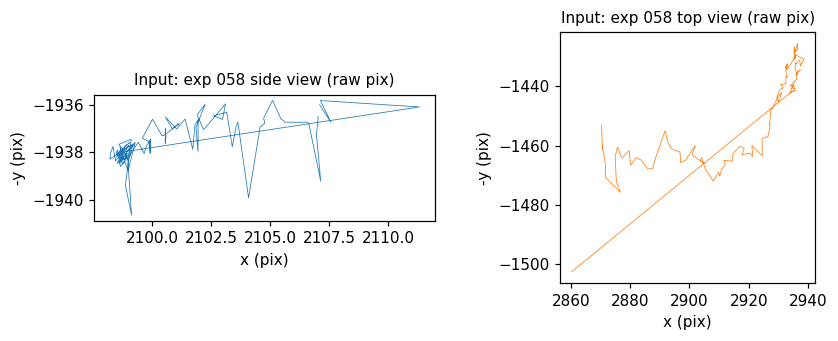

side: 110 rows | top: 112 rows (raw tracked box centers)


In [ ]:
print(f'{len(data_panda)} event rows after filtering (columns: {list(data_panda.columns)})\n')
display(data_panda[['Exp_num', 'View', 'Camera', 'Straw_Weight(gr)',
                    'Straw_Length(cm)', 'Top_pix2cm', 'Side_pix2cm',
                    'First_contact_frame', 'Slip/Twine_frame', 'Twine_status']])

# raw trajectories of the example event (exp 058) parsed with the authors' reader
sx, sy, st, sidx, sN = funcget_tracked_data(os.path.join(track_folder_path, 'CSRT_058_side_1.txt'))
tx, ty, tt, tidx, tN = funcget_tracked_data(os.path.join(track_folder_path, 'CSRT_058_top_1.txt'))
fig, axs = plt.subplots(1, 2, figsize=(8, 3.2), dpi=110)
axs[0].plot(sx, -np.array(sy), lw=0.5, color='tab:blue')
axs[0].set_title('Input: exp 058 side view (raw pix)', fontsize=10)
axs[1].plot(tx, -np.array(ty), lw=0.5, color='tab:orange')
axs[1].set_title('Input: exp 058 top view (raw pix)', fontsize=10)
for ax in axs:
    ax.set_xlabel('x (pix)'); ax.set_ylabel('-y (pix)'); ax.set_aspect('equal')
plt.tight_layout(); plt.show()
print(f'side: {sN} rows | top: {tN} rows (raw tracked box centers)')

## 8. Populate `Plant`/`Event` instances and compute geometry, angle and force (author notebook cell 4, verbatim)

For every table row this: builds the `Plant` (pixel scales, support length from the hinge distance + measured straw length, support mass), falls back to the excel circumnutation period when the `Measurements/` image folder is absent (authors' designed fallback), then for each event computes the tracked support vector `xyz` (cm, relative to equilibrium), the contact-point position projected from the contact tracking (`pz` scaling), the deflection angle `α = asin(r_xy / L_tracked)`, and finally the force time series `F_bean` via the torque equilibrium. The `tqdm` bar should show 10/10 rows; the authors' cell prints and skips events whose track files are absent by design. 各イベントの幾何・角度・力を著者コードのまま計算します。

In [ ]:
# clear plants and events
plants = []
events = []
#%% populate plant and event instances
i = 0
N = len(data_panda)
for i in tqdm(range(N)): # N
    try:
        exp = int(re.findall('\d{3,4}',data_panda.at[i,'Exp_num'])[0]) # exp num
        view = data_panda.at[i,'View']  # side of top view
        if view == 'top':
            plants[-1].pix2cm_t = float(data_panda.at[i,'Top_pix2cm'])

        if i==0 or exp!=plants[-1].exp_num: # append new plant with data from pandas
            #basic data
            plants.append(article0_funcs.Plant(data_panda,data_path,i,exp))
            # view dependent data
            plants[-1].view_data(data_panda,i)
            # circumnutation data
            plants[-1].cn_data(data_panda,i)
            #Youngs modulus by segment with avg
            # plants[-1].getE(E_dict)


        event =  int(re.findall('_[0-9]',data_panda.at[i,
        'Exp_num'])[0].replace('_','')) # get event number


        # if this is the 1st event or the previous event_num is different from the current one:
        # add new event to list
        if len(events)==0 or events[-1].event_num != event or \
            events[-1].p.exp_num != exp:
            events.append(article0_funcs.Event(plants[-1],data_panda,i))
        events[-1].event_num = event

        # view dependent data
        events[-1].view_data(data_panda,i,view)

        # get automated extraction of twine(decision) time
        # events[-1].get_twine_time(exp,event,view,
        #                   h5_dict,near_sup_track_dict,50,track_dict,to_plot=0)


        # get track data, select decision period data, pix2cm,
        events[-1].event_base_calcs(view,track_dict,contact_dict)
        # calc
        events[-1].event_calc_variables(view)
        # print(f'i={i}, exp number {exp}, {event}') # print progress
    except Exception as e:
        print(f'Error at i={i}, exp number {exp}, {event}')
        print(e)
        
        continue


<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_11509/2092624545.py:9: SyntaxWarning: invalid escape sequence '\d'
  exp = int(re.findall('\d{3,4}',data_panda.at[i,'Exp_num'])[0]) # exp num


  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:00<00:00, 112.40it/s]

new_y_pos_supp_bot(pixels) is NaN, using original support base z position
new_y_pos_supp_bot(pixels) is NaN, using original support base z position


## 9. Result A — deflection, angle and force trajectory of the example event (author notebook cell 5, verbatim)

Reproduces the authors' example figure for event index 4 (plant exp `058`): panel **A** shows the tracked support displacement Δx, Δy, Δz (cm) and the deflection angle α (deg) over time; panel **B** shows the extracted force `F` (mN) with the contact-point distance `l_c` (cm) along the support. This is the paper's Fig.-type force-trajectory product for one shoot–support contact. 力の軌跡（結果A）を再現します。

Slip:False


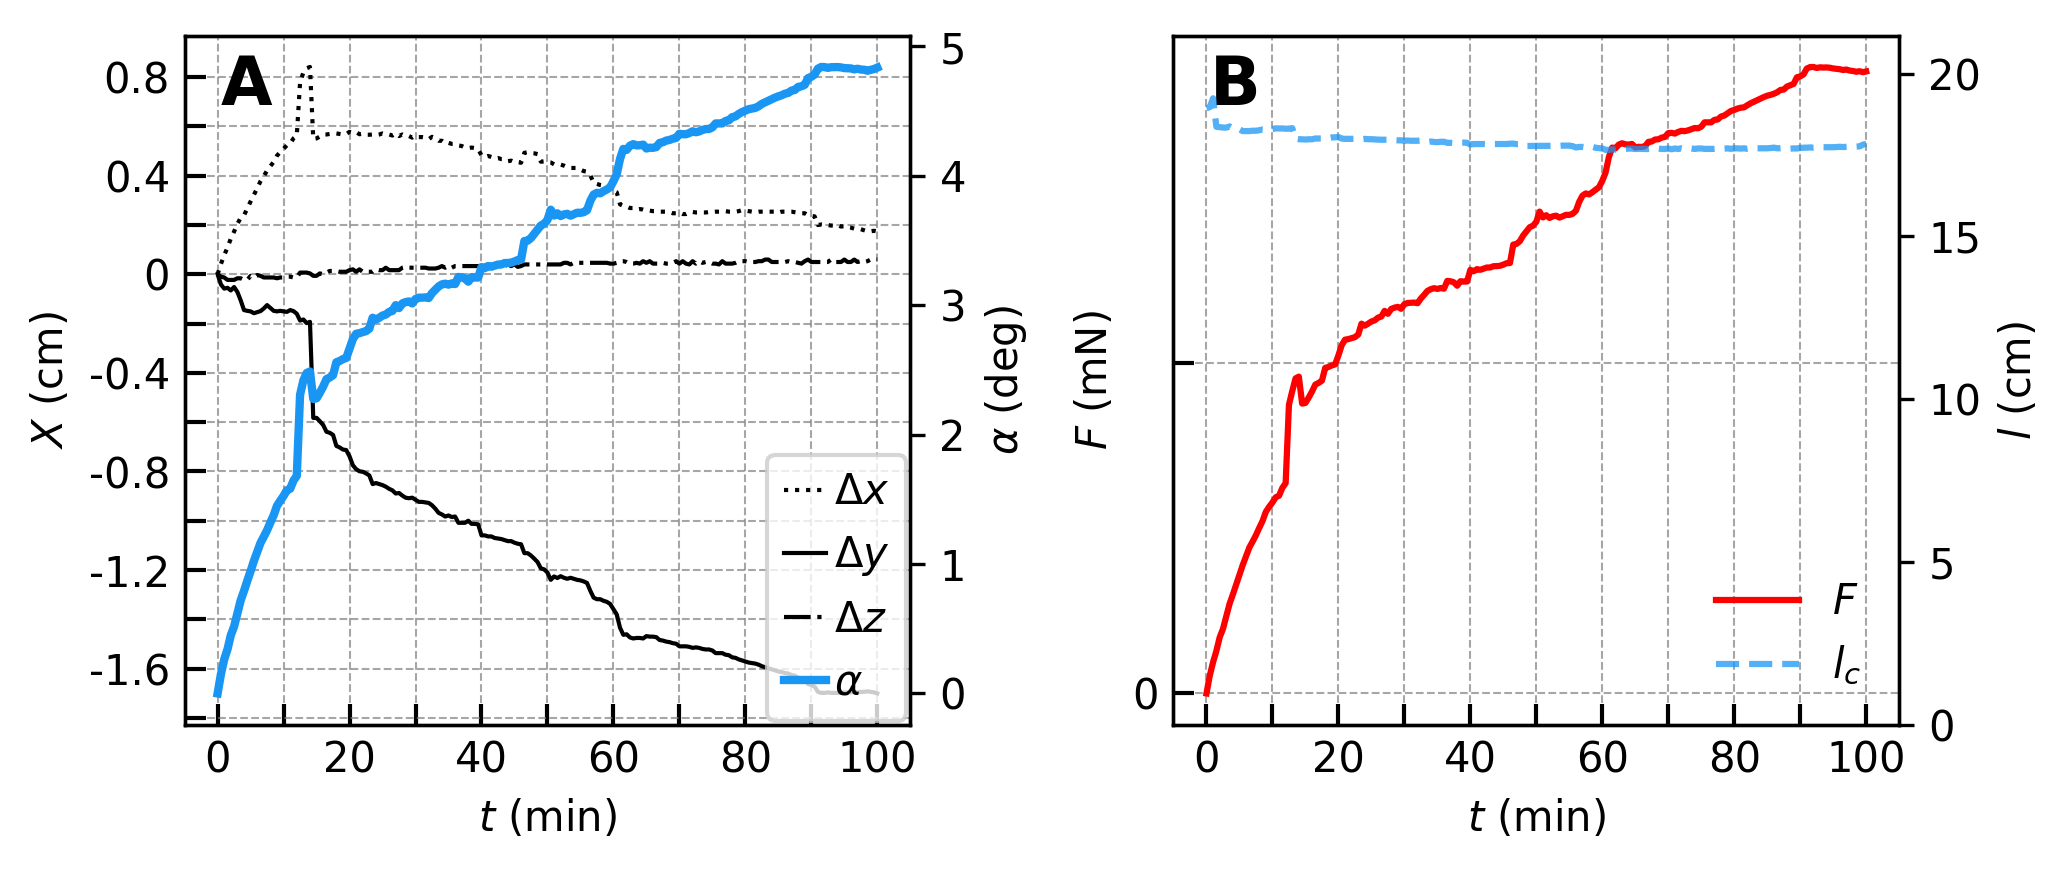

In [ ]:
# Force trajectory for slip event with contact position along support
# cmap = plt.get_cmap('viridis')
cmap = plt.get_cmap('rainbow')
# i_exmp = 60 # 40 (simple) , 20,120 (bump from dist2tip)
i_exmp = 4
event_exmp = events[i_exmp]
max_time = event_exmp.timer[-1]/60

# check events are correctly classified
print("Slip:"+ str( event_exmp.twine_state==0))

fig, axs = plt.subplots(1, 2, figsize=(7, 3), dpi=300)
# add subplot labels
axs[0].text(0.05, 0.9, 'A', fontsize=fs, fontweight='bold', transform=axs[0].transAxes)
axs[1].text(0.05, 0.9, 'B', fontsize=fs, fontweight='bold', transform=axs[1].transAxes)

# Plot xyz coordinates
xyz = event_exmp.xyz
axs[0].plot(event_exmp.timer/60, xyz[0,::]-xyz[0,0], color='black', 
            linestyle = 'dotted', linewidth = 1, label=r'$\Delta x$') #cmap(0.1)
axs[0].plot(event_exmp.timer/60, xyz[1,::]-xyz[1,0], color='black', 
            linestyle = '-', linewidth = 1, label=r'$\Delta y$') #cmap(0.5)
axs[0].plot(event_exmp.timer/60, xyz[2,::]-xyz[2,0], color='black', 
            linestyle = 'dashdot', linewidth = 1, label=r'$\Delta z$') #cmap(0.9)

# Plot angle on the same figure with different axis
axs0 = axs[0].twinx()
axs0.plot(event_exmp.timer/60, np.rad2deg(event_exmp.alpha), color=cmap(0.2), linewidth = 2, label=r'$\alpha$') #cmap(0.2)
# add legend label from the twin axis
lines, labels = axs[0].get_legend_handles_labels()
lines2, labels2 = axs0.get_legend_handles_labels()

# set axis and grid
axs[0].set_xlabel(r'$t$ (min)')
axs[0].set_ylabel(r'$X$ (cm)')
# axs0.set_ylim([0,10])
# set_grid(axs[0],max_time,5)
set_grid(axs[0],max_time,2)

# axs0.set_xlabel(r'$t$ (min)')
axs0.set_ylabel(r'$\alpha$ (deg)')

# Adjust the legend properties

axs[0].legend(
    lines + lines2, labels + labels2,
    loc='lower right',          # Place legend
    frameon=True,              # Remove the frame
    handlelength=1,             # Shorter line elements
    handletextpad=0.2,          # Reduce space between handle and text
    borderaxespad=0.1,          # Reduce space between legend and inset plot edge
    fontsize=10                 # Smaller font size for better fit
)


###########################################
# Plot calculated force and contact position

axs[1].plot(event_exmp.timer/60, event_exmp.F_bean,
             color=cmap(1.5), label=r'$F$') #cmap(0.2)
ax2 = axs[1].twinx()
dist2tip = [abs(k) for k in event_exmp.l_contact] # ?
# ax2.plot(event_exmp.timer/60, dist2tip, color='gray', label=r'$l$', alpha=0.75) # cmap(0.7)

# axs[1].vlines(event_exmp.timer[-1]/60, 0, event_exmp.F_bean[-1]*mg2mN,
#                color=cmap(1.5), linestyle='dotted')
ax2.plot(event_exmp.timer/60, dist2tip, color= cmap(0.2), linestyle='dashed',
          label=r'$l_c$', alpha=0.75)
lines, labels = axs[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axs[1].legend(lines + lines2, labels + labels2, loc='best',frameon=False)



# draw a small downward arrow at rapid force increase
x0 = 29
y0 = 0.65
axs[1].annotate(
    '',                    # no text
    xy=(x0, y0),           # arrow tip
    xytext=(x0, y0 + 0.1), # arrow tail (0.5 units above)
    arrowprops=dict(
        arrowstyle='-|>',  # simple arrow head
        lw=0.75,            # line width of arrow shaft
        mutation_scale=5, # size of arrow head
        color='black'
    )
)

ax2.set_ylabel(r'$l$ (cm)')
ax2.set_ylim([0,max(dist2tip)*1.1])
axs[1].set_xlabel(r'$t$ (min)')
axs[1].set_ylabel(r'$F$ (mN)')
set_grid(axs[1],max_time,0.5)
# set_grid(ax2,max_time,17.5)

plt.tight_layout()
plt.show()

## 10. Result B — force calibration and measurement noise (author notebook cell 6, two marked path adaptations)

Panel **A**: the authors' static calibration — known weights hung over a pulley (`mg`, mN) versus the force measured by the pipeline (`F`, mN), linear fit with errors. Panel **B**: tracking noise from `Fluctuations/CSRT_fluctuations_1sec_interval.txt` (free pendulum, 1 s interval), with the σ-noise circle inset, and printed error-propagation numbers (`d_alpha_noise`, minimum detectable force `F_min_mN`).

`# ADAPTED` (Windows→Linux, identical SHA-1-verified files): the original referenced `r'fluctuations\...'` → `Data/Fluctuations/` (repository case) and `r'Force calibration\force_calibration_curve.xlsx'` → `os.path.join(data_path, 'Force calibration', ...)`. キャリブレーションとノイズ評価（結果B）を再現します。

50
['2619.0', ' 1991.0', ' 144.0', ' 116.0', ' C:\\Users\\Amir\\Documents\\PHD\\Experiments\\Force Measurements\\Exp2_Pendulum\\Calibrations\\fluctuations_1sec_int\\DSC_8205.JPG', ' 2024-05-11 13:07', ' 0', ' Auto\n']
100
['2640.0', ' 1994.0', ' 120.0', ' 97.0', ' C:\\Users\\Amir\\Documents\\PHD\\Experiments\\Force Measurements\\Exp2_Pendulum\\Calibrations\\fluctuations_1sec_int\\DSC_8255.JPG', ' 2024-05-11 13:08', ' 0', ' Auto\n']
pix2cm=0.0019 cm/pix,std_noise=0.096 mm
d_alpha_noise=0.00029 rad , np.rad2deg(d_alpha_noise)=0.016 deg
err_res_pix=7.1 cm/pix,err_res_mm=0.13 mm
D_mm=20 mm,dD_mm=0.16 mm,L_mm=1.8e+02 mm,dL_mm=0.13 mm,h_tip_mm=12 mm,      dh_tip_mm=0.13 mm,A=0.059,alpha_error_calc=0.0005 rad, F_min_mN=0.002 mN


/tmp/ipykernel_11509/201129842.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


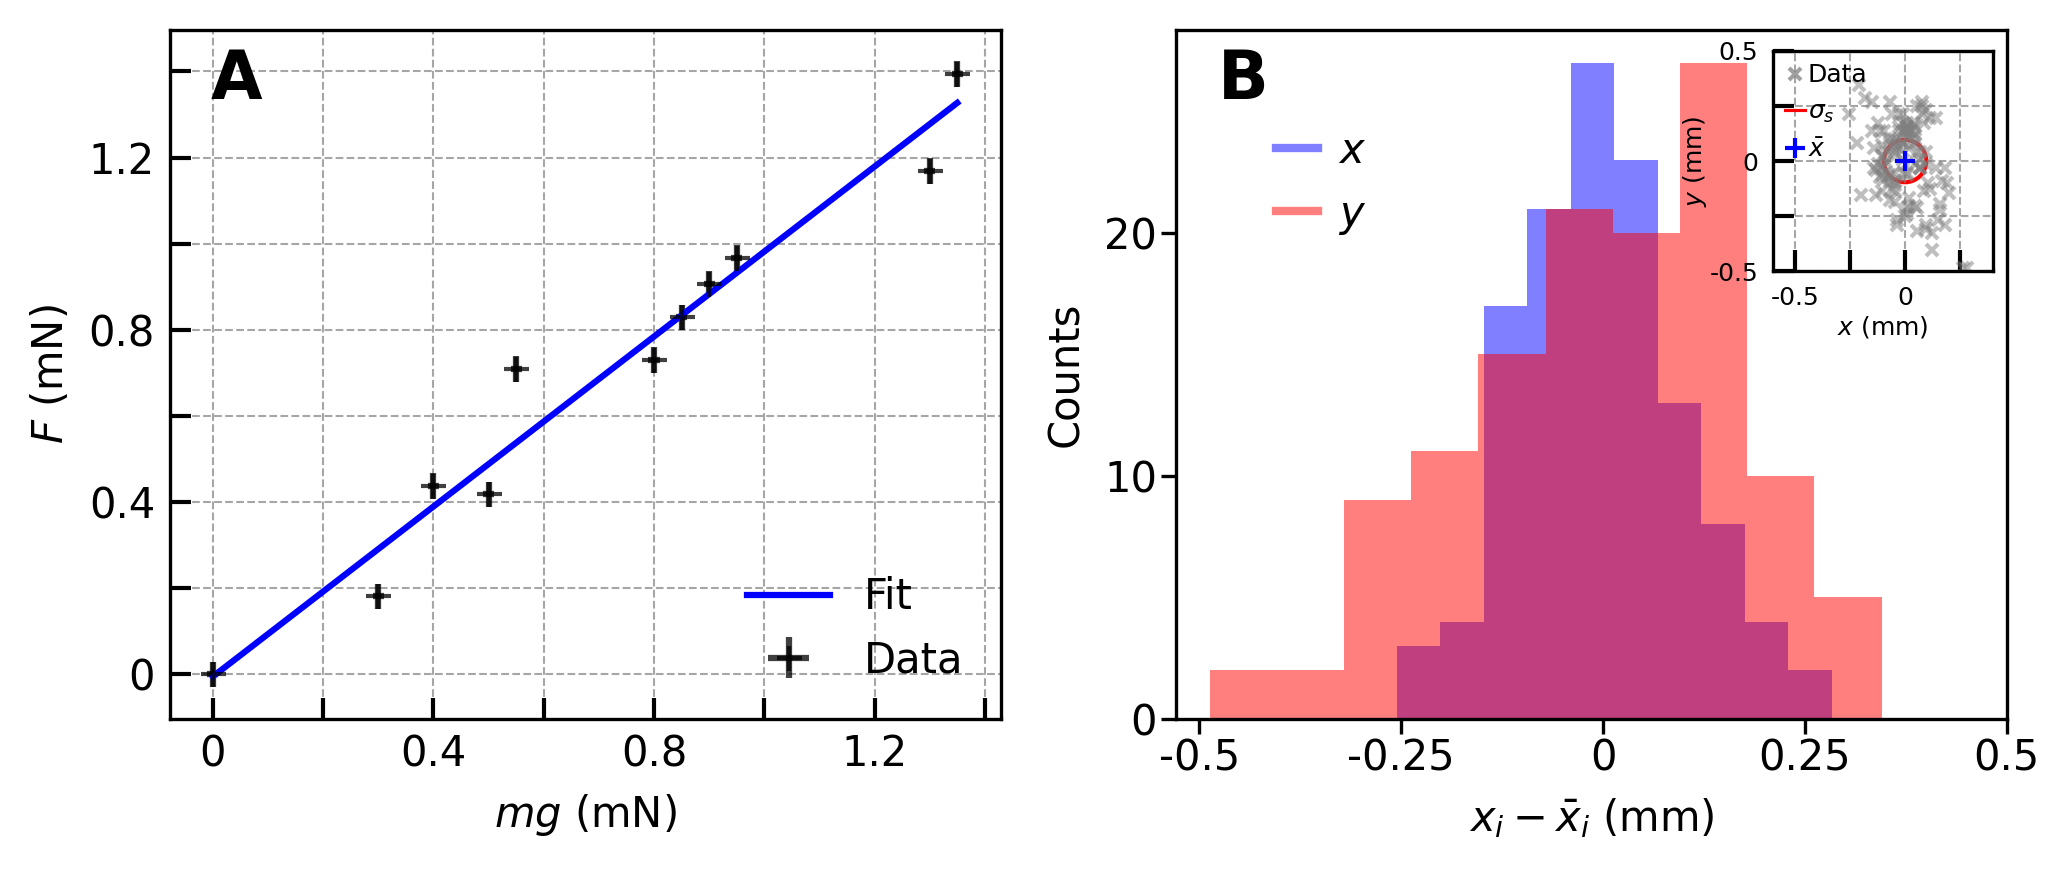

In [ ]:
# combined plot of calibration (A) and noise (B)

# test = r"C:\Users\Amir\Documents\PHD\Python\GitHub\Amir_Repositories\Repo_article0\CSRT_fluctuations_1sec_interval.txt"
fluctuation_track_file = os.path.join(data_path, 'Fluctuations', 'CSRT_fluctuations_1sec_interval.txt')  # ADAPTED: Linux path case/separators


xcntr,ycntr,timer,index,N = funcget_tracked_data(fluctuation_track_file)
pend_diam_pix = 423 # width of the pendulum from top view
pend_diam_cm = 0.8
L_cm = 18 
pix2cm = pend_diam_cm/pend_diam_pix 
L_mm = L_cm*10
h_tip = np.mean([events[i].L_track2suptip_cm for i in range(len(events))])
h_tip_mm = h_tip*10

fig, ax = plt.subplots(1, 2, figsize=(7, 3), dpi=300)
ax[0].text(0.05, 0.9, 'A', fontsize=fs, fontweight='bold', transform=ax[0].transAxes)
ax[1].text(0.05, 0.9, 'B', fontsize=fs, fontweight='bold', transform=ax[1].transAxes)


############################################################
x = np.subtract(xcntr, np.mean(xcntr))*pix2cm*10 # x10 for mm
y = np.subtract(ycntr, np.mean(ycntr))*pix2cm*10 # x10 for mm

# Plot the distribution
ax[1].hist(x, alpha=0.5, color='blue', label=r'$x$')
ax[1].hist(y, alpha=0.5, color='red', label=r'$y$')
ax[1].set_xlabel(r'$x_{i} - \bar{x}_{i}$ (mm)')
ax[1].set_ylabel('Counts')
# Control x-tick and y-tick positions
ax[1].set_xticks([-0.5, -0.25, 0, 0.25, 0.5])  # Set specific tick positions
ax[1].set_xticklabels([-0.5, -0.25, 0, 0.25, 0.5], fontsize=10)  # Set specific tick labels with fontsize
ax[1].set_yticks([0, 10, 20])  # Set specific y-tick positions
ax[1].set_yticklabels([0, 10, 20], fontsize=10)  # Set specific y-tick labels with fontsize
# Adjust tick labels' padding
ax[1].tick_params(axis='x', pad=1)  # Move x-axis labels closer to the ticks
ax[1].tick_params(axis='y', pad=1)  # Move y-axis labels closer to the ticks

# Create a custom legend element for the noise distribution
legend_elements = [
    Line2D([0], [0], color='blue',alpha=0.5, lw=2, linestyle='-', label=r'$x$'),  # Data points
    Line2D([0], [0], color='red', lw=2, alpha=0.5, linestyle='-', label=r'$y$'),  # Straight red line
]
# ax[1].legend(loc='best',frameon=False)
# Add the custom legend elements to the plot
ax[1].legend(
    handles=legend_elements,
    loc='upper left',          # Place in the upper-right corner
    frameon=False,              # Remove the frame
    handlelength=1,             # Shorter line elements
    handletextpad=0.5,          # Reduce space between handle and text
    borderaxespad=2,          # Reduce space between legend and inset plot edge
    fontsize=10                 # Smaller font size for better fit
)


############################################################
# Create inset axes
ax_inset = inset_axes(ax[1], width="40%", height="40%",# loc='upper right',
                      bbox_to_anchor=(0.22, 0.2,0.82,0.8), bbox_transform=ax[1].transAxes)
ax_inset.set_ylim([-0.5,0.5])
ax_inset.set_xlim([-0.6,0.4])
ax_inset.set_xlabel(r'$x$ (mm)',fontsize=6,labelpad=1)
ax_inset.set_ylabel(r'$y$ (mm)',fontsize=6,labelpad=0)
ax_inset.tick_params(axis='both', length=2)  # Make both x and y axis ticks shorter
ax_inset.tick_params(axis='both', width=0.5)  # Make both x and y axis ticks thinner
ax_inset.tick_params(axis='both', labelsize=6)  # Make both x and y axis labels smaller
set_grid(ax_inset,2.5,2.5)

# Increase the x and y scales of the main plot
# ax[0].set_xlim([-0.4, 0.6])
# ax[0].set_ylim([-0.3, 0.6])
# Ensure the x and y axes are plotted on the same scale
ax_inset.set_aspect('equal', adjustable='box')

# calculate the mean and standard deviation of the data
# calculate mean
ax_inset.plot(x,y,'x',color='grey',alpha=0.5,label = 'Data',markersize=3)
# plot the mean
ax_inset.plot(np.mean(x),np.mean(y),'b+',markersize=5,label={r'$\bar{x}$'})
# calculate the std
std_noise = np.std(np.sqrt(x**2 + y**2)) # in mm
# Plot a thin red circle with a radius of the standard deviation around the mean
circle_noise = plt.Circle((np.mean(x), np.mean(y)), std_noise, color='red', fill=False, linewidth=1,label=r'$\sigma_{noise}$')
# Plot a thin red circle with a radius of the pendulum around the mean
circle_diameter = plt.Circle((np.mean(x), np.mean(y)), pend_diam_cm/2*10, color='red', fill=False, linewidth=0.5)
# plt.gca().add_artist(circle_diameter)
ax_inset.add_artist(circle_noise)

# Create a custom legend element for the noise and data
legend_elements = [
    Line2D([0], [0], marker='x', color='grey', markersize=3, alpha=0.75, linestyle='None', label='Data'),  # Data points
    Line2D([0], [0], color='red', lw=0.75, linestyle='-', label=r'$\sigma_{s}$'),  # Straight red line
    Line2D([0], [0], marker='+', color='blue', markersize=5, linestyle='None', label=r'$\bar{x}$') # mean point
]

# Adjust the legend properties
ax_inset.legend(
    handles=legend_elements,
    loc='upper left',          # Place in the upper-right corner
    frameon=False,              # Remove the frame
    handlelength=0.8,           # Shorter line elements
    handletextpad=0.1,          # Reduce space between handle and text
    borderaxespad=0.1,          # Reduce space between legend and inset plot edge
    fontsize=6                  # Smaller font size for better fit
)

############################################################
# errors
std_noise = np.std(np.sqrt(x**2 + y**2)) # in mm
print(f'{pix2cm=:.2g} cm/pix,{std_noise=:.2g} mm')
d_alpha_noise = m.asin((std_noise/2)/(L_mm-h_tip_mm))
print(f'{d_alpha_noise=:.2g} rad , {np.rad2deg(d_alpha_noise)=:.2g} deg')
# error from resolution:
# distance error is ssq of individual measurement errors ~ 2 pixels per measurement
trk_pix_err = 5 # pixel tracking error estimation 
err_res_pix = m.sqrt(trk_pix_err**2 + trk_pix_err**2)
err_res_mm = err_res_pix*pix2cm*10
print(f'{err_res_pix=:.2g} cm/pix,{err_res_mm=:.2g} mm')

# sum errors from resolution and noise:
D_mm = 20 # mean deflection in mm 
dD_mm = np.sqrt(std_noise**2 + (err_res_pix*pix2cm*10)**2) # in mm
dh_tip_mm = err_res_pix*pix2cm*10
dL_mm = err_res_pix*pix2cm*10
A = D_mm/(2*(L_mm-h_tip_mm))
alpha_error_calc = 1/(1-A**2)*np.sqrt((A*dD_mm/D_mm)**2+(A*dL_mm/(L_mm-h_tip_mm))**2+(A* dh_tip_mm/(L_mm-h_tip_mm))**2)
F_min_mg = 1000*0.8 * m.tan(alpha_error_calc)/2
F_min_mN = F_min_mg * 1e-2
print(f'{D_mm=:.2g} mm,{dD_mm=:.2g} mm,{L_mm=:.2g} mm,{dL_mm=:.2g} mm,{h_tip_mm=:.2g} mm,\
      {dh_tip_mm=:.2g} mm,{A=:.2g},{alpha_error_calc=:.2g} rad, {F_min_mN=:.2g} mN')

############################################################

#%% Calibration graph for force
# file = r"C:\Users\Amir\Documents\PHD\Thesis\My Articles\0 - Flexible dynamic force measurement method via physical pendulum\Data\Force calibration data 1\force_calibration_curve.xlsx"
calibration_data_file = os.path.join(data_path, 'Force calibration', 'force_calibration_curve.xlsx')  # ADAPTED: Linux separators
calib_data = pd.read_excel(calibration_data_file)
calib_data = calib_data.dropna()

column_names = calib_data.columns
x_name = column_names[0]
y_name = column_names[1]
x = calib_data[x_name]
y = calib_data[y_name]


# plot in milli-newton: 1 dyne = 10^-5 N, 1 dyne = 100 mN
# ax[0].text(0.05, 0.9, 'B', fontsize=fs, fontweight='bold', transform=ax[0].transAxes)
x_mN = x/100
y_mN = y/100
fit_w_err(ax[0],x_mN,0.01,y_mN,0.03,fit_func=linfunc, data_color = 'black',fit_color = 'blue',data_alpha = 0.75,add_legend='measure')
ax[0].legend(loc='best',frameon=False)
ax[0].set_xlabel(r'$mg$ (mN)')
ax[0].set_ylabel(r'$F$ (mN)')
set_grid(ax[0],2,2)


plt.tight_layout()
plt.show()

# adjust layout and show
# fig.subplots_adjust(wspace=0.4)  # Adjust the width space between subplotsplt.tight_layout()
fig.subplots_adjust(top=0.95, bottom=0.15, left=0.1, right=0.95)  # Adjust as necessary

# fig.savefig(save_folder+r'\calibration and noise.pdf',dpi=300)

## 11. Small per-event results table + CSV export (added cell, not in the author notebook)

A compact summary of the computed events (added for this notebook; not an author figure/table): twine status, decision-window duration, and the maximum/mean extracted force per event, exported to `force_summary.csv` in the working directory. Values come only from the pipeline above. 各イベントの要約表をCSV保存します。

In [ ]:
rows = []
for ev in events:
    F = np.asarray(ev.F_bean, dtype=float)
    rows.append({'exp_num': ev.p.exp_num, 'event': ev.event_num,
                 'twine_state': int(ev.twine_state),
                 'n_steps': len(ev.timer),
                 'duration_min': ev.timer[-1] / 60.0,
                 'max_F_mN': round(float(F.max()), 4),
                 'mean_F_mN': round(float(F.mean()), 4)})
summary = pd.DataFrame(rows)
display(summary)
summary.to_csv('force_summary.csv', index=False)
print('saved', os.path.join(os.getcwd(), 'force_summary.csv'))

,exp_num,event,twine_state,n_steps,duration_min,max_F_mN,mean_F_mN
0,21,1,1,126,62.5,0.4101,0.2657
1,36,1,1,179,89.0,0.3861,0.1960
2,51,1,1,163,81.0,0.6805,0.3714
3,58,1,0,102,50.5,0.1184,0.0802
4,110,1,1,201,100.0,0.0947,0.0669


saved /content/pendulum_article0/force_summary.csv


## 12. Interpretation, scope and references 解釈と参考文献

**What this demonstration establishes.** The authors' released pipeline runs end-to-end on their example tracking data inside this notebook: it recovers the support deflection geometry, the deflection angle, the contact-point location along the rod, the bi-axial force trajectory for one shoot–support contact event, and the calibration/noise characterization. Author reference values from the pinned notebook's own saved outputs (Windows run) are: 10/10 event rows processed; example event not a slip event (`Slip:False`); `pix2cm=0.0019 cm/pix`, `std_noise=0.096 mm`, minimum detectable force `F_min_mN=0.002 mN`. Compare the printed values here; small differences would indicate an environment/data discrepancy, since the pipeline is deterministic.

**What it does not establish.** This is a single-example re-execution: it does not verify the paper's plant-cohort statistics, the accuracy claims of the full dataset, or the raw-video tracking step (the `Measurements/` circumnutation-image folder and 7.2 GB `Example_images.zip` are intentionally not downloaded; the excel fallback period is used, as designed by the authors' own code when that folder is absent).

**Differences from the authors' setup.** Windows→Linux path fixes (marked `# ADAPTED` above); Colab's package stack instead of the authors' local Python 3.11 environment; `Measurements/` folder absent by design (excel fallback). All analysis mathematics is the authors', unmodified.

**Validation record.** Executed top-to-bottom in a fresh Colab CPU runtime on 2026-10-09 (see the notebook outputs and the run report for the archived execution).

**References.**
- Ohad, A. & Meroz, Y. (2025). Camera-based bi-axial measurement of weak forces generated by freely moving plant organs. *J. Exp. Bot.* 77(4):985–994. DOI: 10.1093/jxb/eraf476
- Ohad, A. & Meroz, Y. (2025). Data and code for: Dual-axial force measurements of non-tethered plants. Zenodo. DOI: 10.5281/zenodo.15545548 (CC-BY-4.0)
- Code: github.com/merozlab/Ohad2025_PendulumForceMeasure @ `c4b7f7b05e559aeb22c596f163e9ccfd1e607b70` (branch `Article0_v3`). Repository license file not observed at the pinned commit; the Zenodo data deposit is CC-BY-4.0. This notebook is an independent educational reproduction, not authored or endorsed by the authors.